# Thesis Figure Generation

This notebook reproduces the result figures 3-7 used in the Results section of the MSci thesis project.

The notebook is organised so that:

- shared imports, colours, and helper functions are defined once at the top;
- each figure has its own labelled section;
- figures can be saved reproducibly into `results/figures/`

In [2]:
# Core imports used throughout the figure-generation notebook
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Project paths
# -----------------------------------------------------------------------------
# Recommended repo layout:
# results/
#   All_Figures_cleaned.ipynb
#   figures/
#   data/                 # optional: put exported TSV/CSV summary files here

RESULTS_DIR = Path(".")
FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

# If you move your TSV/CSV files into the repo, replace the hard-coded Windows
# paths in the relevant sections with paths relative to RESULTS_DIR, e.g.:
# DATA_DIR = RESULTS_DIR / "data"

# -----------------------------------------------------------------------------
# Shared plotting constants
# -----------------------------------------------------------------------------
C_EMMA = "#E8735A"
C_MARC = "#8E6BB5"
C_HDBSCAN = "#4472C4"
C_ESM2 = "#1f7f6f"
C_PROSTT5 = "#c94f29"

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
})


def style_ax(ax):
    """Apply common axis styling used across thesis figures."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)


def save_figure(fig, filename_stem):
    """Save a figure as both PNG and PDF for thesis/repo use."""
    fig.savefig(FIGURE_DIR / f"{filename_stem}.png", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename_stem}.pdf", bbox_inches="tight")


## Figure 3 – EC4 purity across three CATH superfamilies

Compares the reported baseline method for each superfamily against the HDBSCAN ProstT5 baseline.

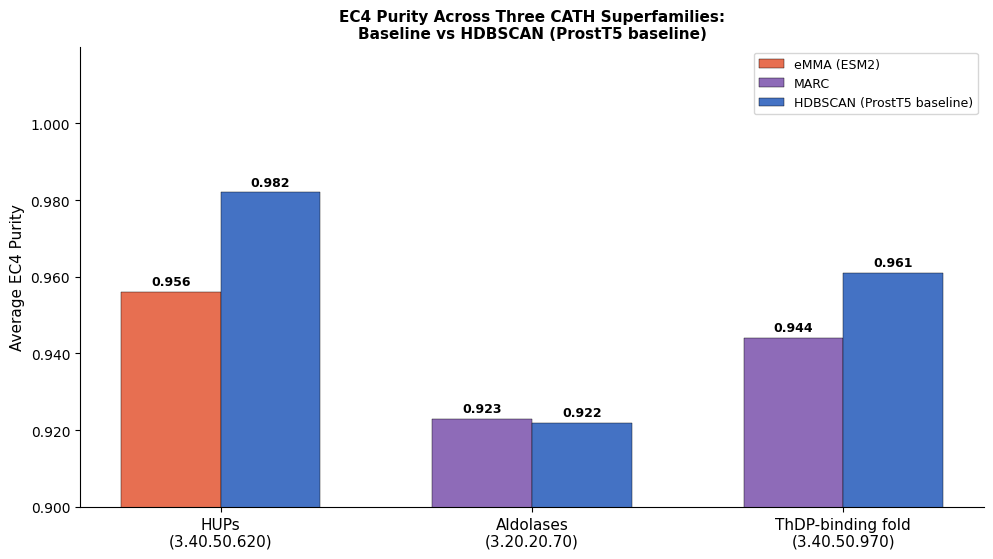

In [4]:
labels = ["HUPs\n(3.40.50.620)", "Aldolases\n(3.20.20.70)", "ThDP-binding fold\n(3.40.50.970)"]

# Values shown in the figure
emma = [0.956, np.nan, np.nan]
marc = [np.nan, 0.923, 0.944]
hdbscan = [0.982, 0.922, 0.961]

x = np.arange(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(10.04, 5.70), dpi=100)

colors = {
    "eMMA (ESM2)": "#e76f51",
    "MARC": "#8e6bb8",
    "HDBSCAN (ProstT5 baseline)": "#4472c4",
}

b1 = ax.bar(x - width/2, emma, width, label="eMMA (ESM2)",
            color=colors["eMMA (ESM2)"], edgecolor="black", linewidth=0.3)
b2 = ax.bar(x - width/2, marc, width, label="MARC",
            color=colors["MARC"], edgecolor="black", linewidth=0.3)
b3 = ax.bar(x + width/2, hdbscan, width, label="HDBSCAN (ProstT5 baseline)",
            color=colors["HDBSCAN (ProstT5 baseline)"], edgecolor="black", linewidth=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.001,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

ax.set_title(
    "EC4 Purity Across Three CATH Superfamilies:\n"
    "Baseline vs HDBSCAN (ProstT5 baseline)",
    fontsize=11,
    fontweight="bold"
)
ax.set_ylabel("Average EC4 Purity", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylim(0.900, 1.020)
ax.set_yticks(np.arange(0.900, 1.001, 0.020))
ax.yaxis.set_major_formatter(lambda v, pos: f"{v:.3f}")

ax.legend(loc="upper right", frameon=True, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## Figure 4 – HUPs superfamily summary metrics

Four-panel summary comparing eMMA against HDBSCAN for the HUPs superfamily.

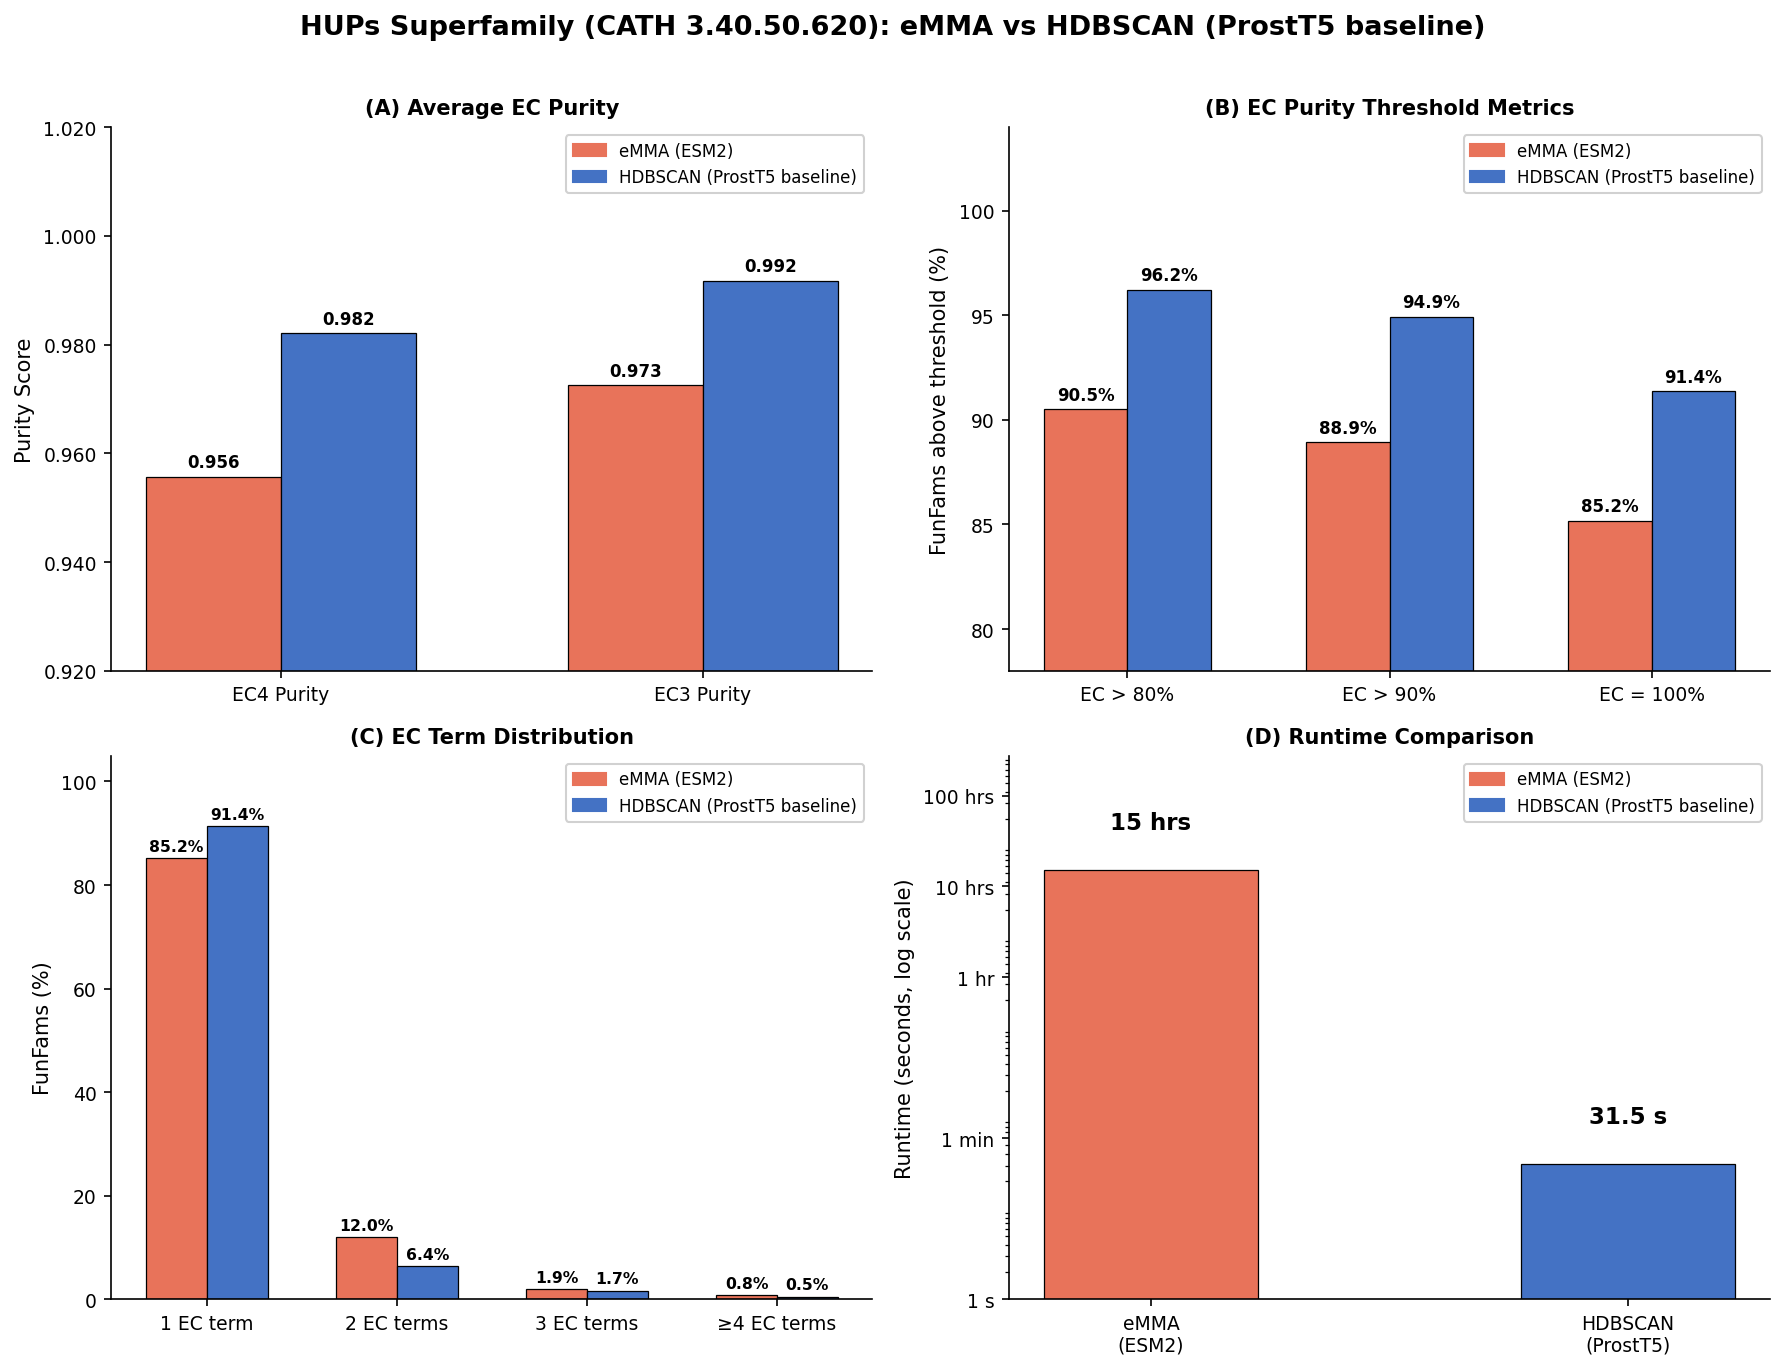

Figure saved to hups_4panel_figure.png


In [6]:
# ── colours ──────────────────────────────────────────────────────────────────
C_EMMA   = '#E8735A'   # warm orange-red  → eMMA / baseline reference
C_HDBSCAN = '#4472C4'  # UCL blue          → HDBSCAN ProstT5 baseline

# ── Panel 1: Average EC4 and EC3 purity ──────────────────────────────────────
p1_metrics   = ['EC4 Purity', 'EC3 Purity']
p1_emma      = [0.9557, 0.9725]   # eMMA (ESM2)
p1_hdbscan   = [0.9821, 0.9917]   # HDBSCAN ProstT5 baseline

# ── Panel 2: Percentage threshold metrics (%FunFams above EC purity threshold)
p2_thresholds = ['EC > 80%', 'EC > 90%', 'EC = 100%']
p2_emma       = [90.52, 88.94, 85.18]   # eMMA (ESM2)
p2_hdbscan    = [96.23, 94.94, 91.38]   # HDBSCAN ProstT5 baseline

# ── Panel 3: %x EC distribution (%FunFams with exactly 1, 2, 3, ≥4 EC terms)
p3_categories = ['1 EC term', '2 EC terms', '3 EC terms', '≥4 EC terms']
p3_emma       = [85.18, 12.03, 1.94, 0.85]   # eMMA (ESM2)
p3_hdbscan    = [91.38,  6.36, 1.72, 0.54]   # HDBSCAN ProstT5 baseline

# ── Panel 4: Runtime comparison (seconds, log scale) ─────────────────────────
p4_methods  = ['eMMA\n(ESM2)', 'HDBSCAN\n(ProstT5)']
p4_runtimes = [15 * 3600, 31.5]   # 15 hrs → seconds; 31.5 s
p4_labels   = ['15 hrs', '31.5 s']


C_EMMA    = '#E8735A'
C_HDBSCAN = '#4472C4'

p1_metrics   = ['EC4 Purity', 'EC3 Purity']
p1_emma      = [0.9557, 0.9725]
p1_hdbscan   = [0.9821, 0.9917]

p2_thresholds = ['EC > 80%', 'EC > 90%', 'EC = 100%']
p2_emma       = [90.52, 88.94, 85.18]
p2_hdbscan    = [96.23, 94.94, 91.38]

p3_categories = ['1 EC term', '2 EC terms', '3 EC terms', '≥4 EC terms']
p3_emma       = [85.18, 12.03, 1.94, 0.85]
p3_hdbscan    = [91.38,  6.36, 1.72, 0.54]

p4_methods  = ['eMMA\n(ESM2)', 'HDBSCAN\n(ProstT5)']
p4_runtimes = [15 * 3600, 31.5]
p4_labels   = ['15 hrs', '31.5 s']

legend_handles = [
    mpatches.Patch(color=C_EMMA,    label='eMMA (ESM2)'),
    mpatches.Patch(color=C_HDBSCAN, label='HDBSCAN (ProstT5 baseline)'),
]

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('HUPs Superfamily (CATH 3.40.50.620): eMMA vs HDBSCAN (ProstT5 baseline)',
             fontsize=13, fontweight='bold', y=1.01)
ax1, ax2, ax3, ax4 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

# P1 — Average EC purity (3 dp)
x1 = np.arange(len(p1_metrics)); w1 = 0.32
b1e = ax1.bar(x1-w1/2, p1_emma,    w1, color=C_EMMA,    edgecolor='black', linewidth=0.6)
b1h = ax1.bar(x1+w1/2, p1_hdbscan, w1, color=C_HDBSCAN, edgecolor='black', linewidth=0.6)
ax1.set_xticks(x1); ax1.set_xticklabels(p1_metrics, fontsize=10)
ax1.set_ylabel('Purity Score', fontsize=10)
ax1.set_title('(A) Average EC Purity', fontweight='bold', fontsize=10)
ax1.set_ylim(0.92, 1.02)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.3f}'))
for bar, val in zip(list(b1e)+list(b1h), p1_emma+p1_hdbscan):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.legend(handles=legend_handles, fontsize=8, loc='upper right', framealpha=0.9)
style_ax(ax1)

# P2 — Threshold metrics
x2 = np.arange(len(p2_thresholds)); w2 = 0.32
b2e = ax2.bar(x2-w2/2, p2_emma,    w2, color=C_EMMA,    edgecolor='black', linewidth=0.6)
b2h = ax2.bar(x2+w2/2, p2_hdbscan, w2, color=C_HDBSCAN, edgecolor='black', linewidth=0.6)
ax2.set_xticks(x2); ax2.set_xticklabels(p2_thresholds, fontsize=9)
ax2.set_ylabel('FunFams above threshold (%)', fontsize=10)
ax2.set_title('(B) EC Purity Threshold Metrics', fontweight='bold', fontsize=10)
ax2.set_ylim(78, 104)
for bar, val in zip(list(b2e)+list(b2h), p2_emma+p2_hdbscan):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.25, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.legend(handles=legend_handles, fontsize=8, loc='upper right', framealpha=0.9)
style_ax(ax2)

# P3 — EC term distribution (linear)
x3 = np.arange(len(p3_categories)); w3 = 0.32
b3e = ax3.bar(x3-w3/2, p3_emma,    w3, color=C_EMMA,    edgecolor='black', linewidth=0.6)
b3h = ax3.bar(x3+w3/2, p3_hdbscan, w3, color=C_HDBSCAN, edgecolor='black', linewidth=0.6)
ax3.set_xticks(x3); ax3.set_xticklabels(p3_categories, fontsize=9)
ax3.set_ylabel('FunFams (%)', fontsize=10)
ax3.set_title('(C) EC Term Distribution', fontweight='bold', fontsize=10)
ax3.set_ylim(0, 105)
for bar, val in zip(list(b3e)+list(b3h), p3_emma+p3_hdbscan):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax3.legend(handles=legend_handles, fontsize=8, loc='upper right', framealpha=0.9)
style_ax(ax3)

# P4 — Runtime (log scale)
b4 = ax4.bar(p4_methods, p4_runtimes, color=[C_EMMA, C_HDBSCAN], edgecolor='black', linewidth=0.6, width=0.45)
ax4.set_yscale('log')
ax4.set_ylabel('Runtime (seconds, log scale)', fontsize=10)
ax4.set_title('(D) Runtime Comparison', fontweight='bold', fontsize=10)
ax4.set_ylim(1, 1e6)
for bar, label, val in zip(b4, p4_labels, p4_runtimes):
    ax4.text(bar.get_x()+bar.get_width()/2, val*2.5, label, ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_yticks([1, 60, 3600, 36000, 360000])
ax4.set_yticklabels(['1 s', '1 min', '1 hr', '10 hrs', '100 hrs'], fontsize=8)
ax4.legend(handles=legend_handles, fontsize=8, loc='upper right', framealpha=0.9)
style_ax(ax4)

plt.tight_layout()
plt.savefig('hups_4panel_figure.png', dpi=1200, bbox_inches='tight')
plt.show()
print('Figure saved to hups_4panel_figure.png')


## Figure 5 – Cluster size distributions

Plots baseline and HDBSCAN FunFam cluster size distributions across the three analysed superfamilies.

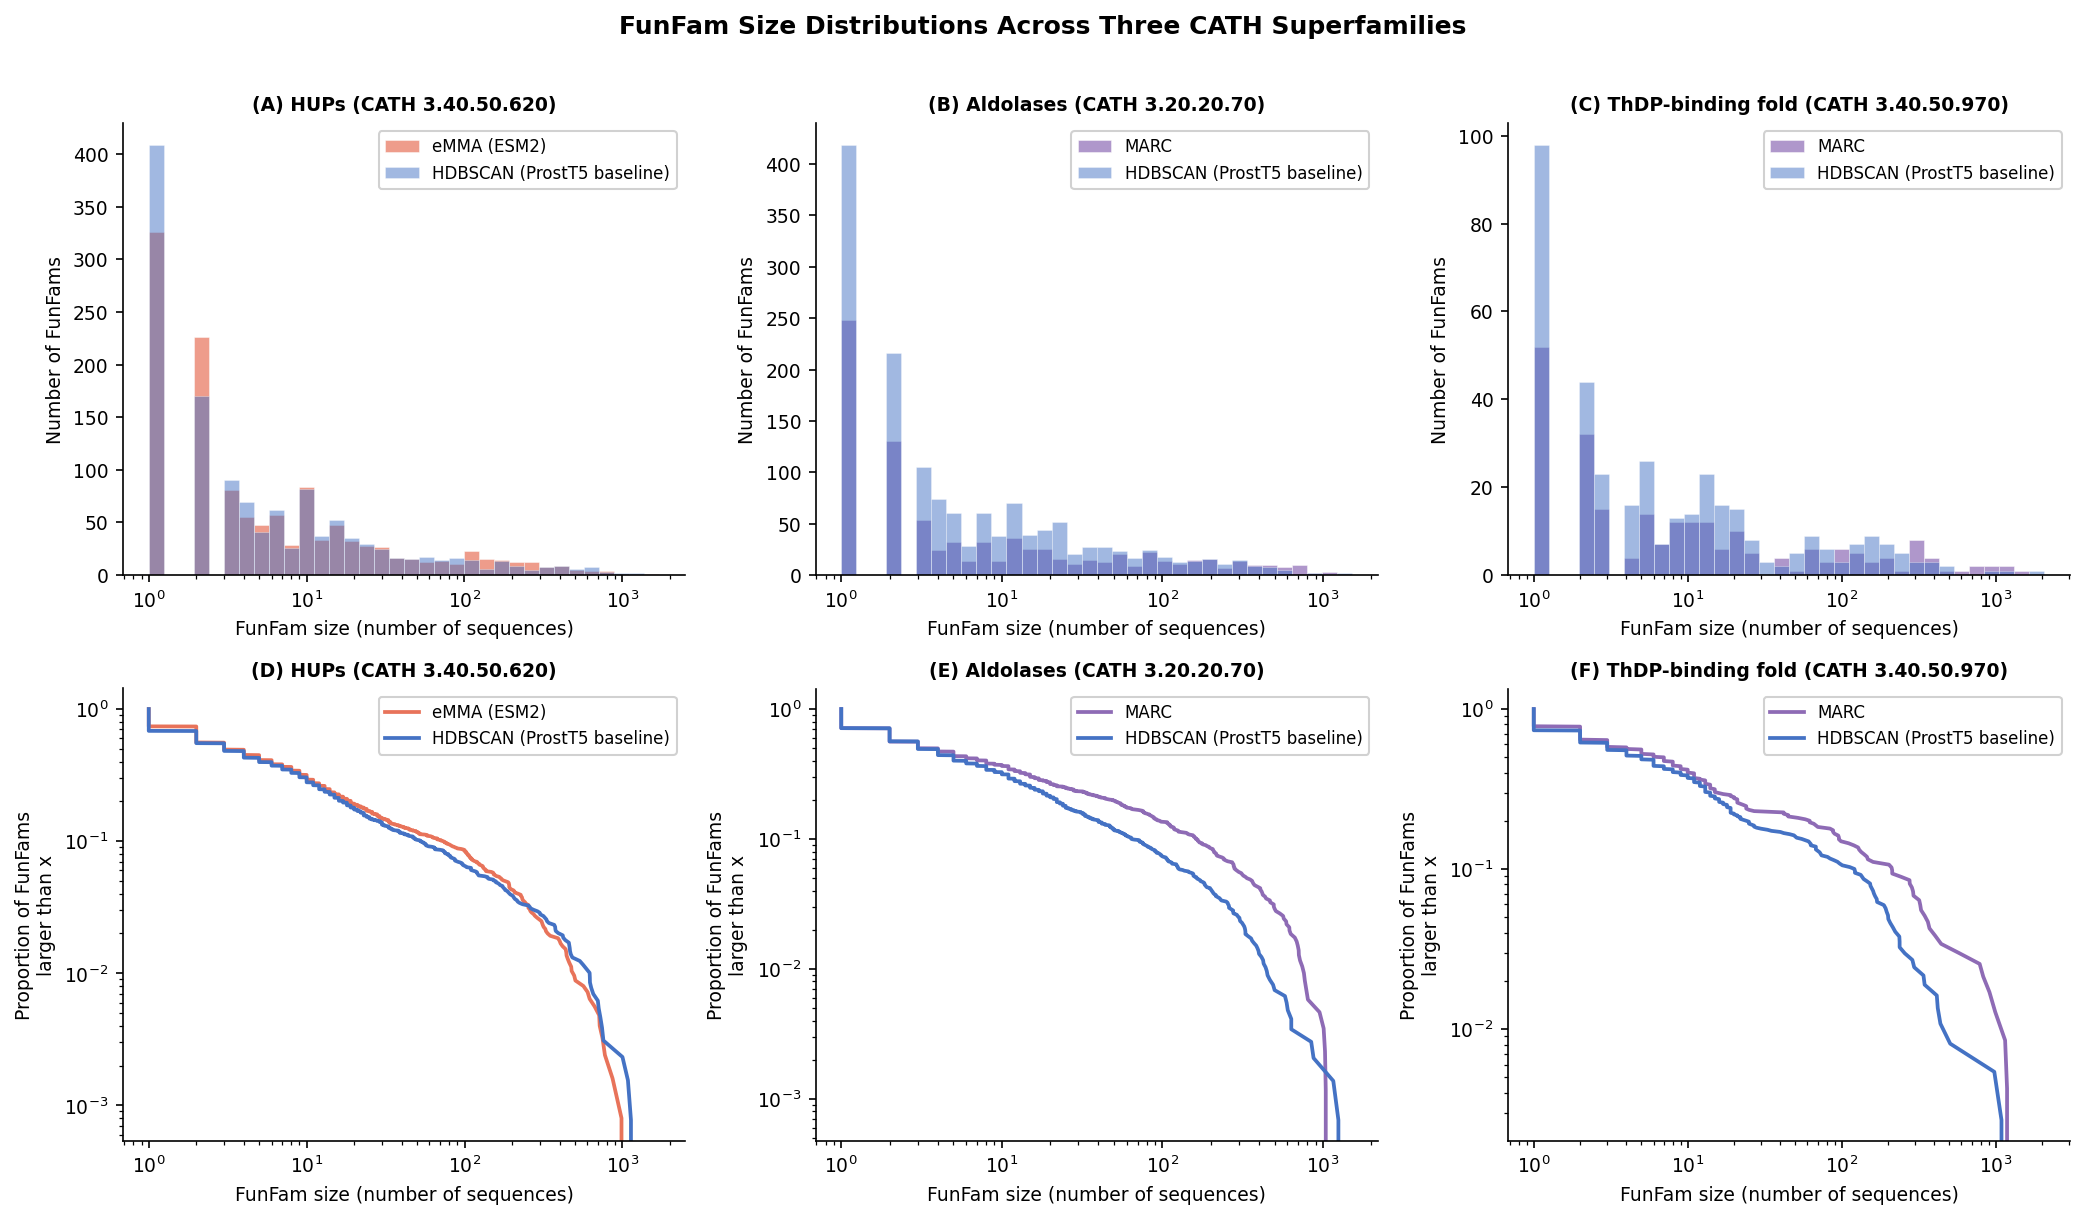

Saved to C:\Users\Janu\funfam_distribution_plots\cluster_size_distributions_all.png


In [8]:
# ── File paths ────────────────────────────────────────────────────────────────
HUPS_EMMA    = r'C:\Users\Janu\funfam_distribution_plots\HUPs\eMMA_esm2.tsv'
HUPS_HDBSCAN = r'C:\Users\Janu\funfam_distribution_plots\HUPs\HDBSCAN_prostt5.tsv'

ALDO_MARC    = r'C:\Users\Janu\funfam_distribution_plots\Aldolases\MARC.tsv'
ALDO_HDBSCAN = r'C:\Users\Janu\funfam_distribution_plots\Aldolases\HDBSCAN_prostt5.tsv'

THDP_MARC    = r'C:\Users\Janu\funfam_distribution_plots\TPP-Binding\MARC.tsv'
THDP_HDBSCAN = r'C:\Users\Janu\funfam_distribution_plots\TPP-Binding\HDBSCAN_prostt5.tsv'

OUTPUT_PATH  = r'C:\Users\Janu\funfam_distribution_plots\cluster_size_distributions_all.png'

C_EMMA    = '#E8735A'
C_MARC    = '#8E6BB5'
C_HDBSCAN = '#4472C4'

def load_tsv(path):
    df = pd.read_csv(path, sep='\t', skiprows=1)
    df.columns = ['funfam', 'num_sequences']
    return df['num_sequences'].values

hups_base = load_tsv(HUPS_EMMA)
hups_hdb  = load_tsv(HUPS_HDBSCAN)
aldo_base = load_tsv(ALDO_MARC)
aldo_hdb  = load_tsv(ALDO_HDBSCAN)
thdp_base = load_tsv(THDP_MARC)
thdp_hdb  = load_tsv(THDP_HDBSCAN)

superfamilies = [
    {'title': 'HUPs (CATH 3.40.50.620)',            'base': hups_base, 'hdb': hups_hdb, 'base_label': 'eMMA (ESM2)', 'base_color': C_EMMA},
    {'title': 'Aldolases (CATH 3.20.20.70)',         'base': aldo_base, 'hdb': aldo_hdb, 'base_label': 'MARC',        'base_color': C_MARC},
    {'title': 'ThDP-binding fold (CATH 3.40.50.970)','base': thdp_base, 'hdb': thdp_hdb, 'base_label': 'MARC',        'base_color': C_MARC},
]

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
panel_labels = [['A', 'B', 'C'], ['D', 'E', 'F']]

for col, sf in enumerate(superfamilies):
    base, hdb = sf['base'], sf['hdb']
    base_label, base_color, title = sf['base_label'], sf['base_color'], sf['title']

    # Row 0: Histogram — baseline first in legend and plotted first
    ax = axes[0, col]
    bins = np.logspace(0, np.log10(max(base.max(), hdb.max()) + 1), 35)
    ax.hist(base, bins=bins, alpha=0.7, color=base_color, label=base_label,            edgecolor='white', linewidth=0.3)
    ax.hist(hdb,  bins=bins, alpha=0.5, color=C_HDBSCAN,  label='HDBSCAN (ProstT5 baseline)', edgecolor='white', linewidth=0.3)
    ax.set_xscale('log')
    ax.set_xlabel('FunFam size (number of sequences)', fontsize=9)
    ax.set_ylabel('Number of FunFams', fontsize=9)
    ax.set_title(f'({panel_labels[0][col]}) {title}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.9)
    style_ax(ax)

    # Row 1: CCDF
    ax = axes[1, col]
    for vals, color, label in [(base, base_color, base_label), (hdb, C_HDBSCAN, 'HDBSCAN (ProstT5 baseline)')]:
        sorted_vals = np.sort(vals)
        ccdf = 1 - np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, ccdf, color=color, linewidth=1.8, label=label)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('FunFam size (number of sequences)', fontsize=9)
    ax.set_ylabel('Proportion of FunFams\nlarger than x', fontsize=9)
    ax.set_title(f'({panel_labels[1][col]}) {title}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.9)
    style_ax(ax)

plt.suptitle('FunFam Size Distributions Across Three CATH Superfamilies',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=1200, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_PATH}')


## Figure 6 – EC4 split-count / fragmentation analysis

Summarises how EC4 terms are consolidated or fragmented across FunFams.

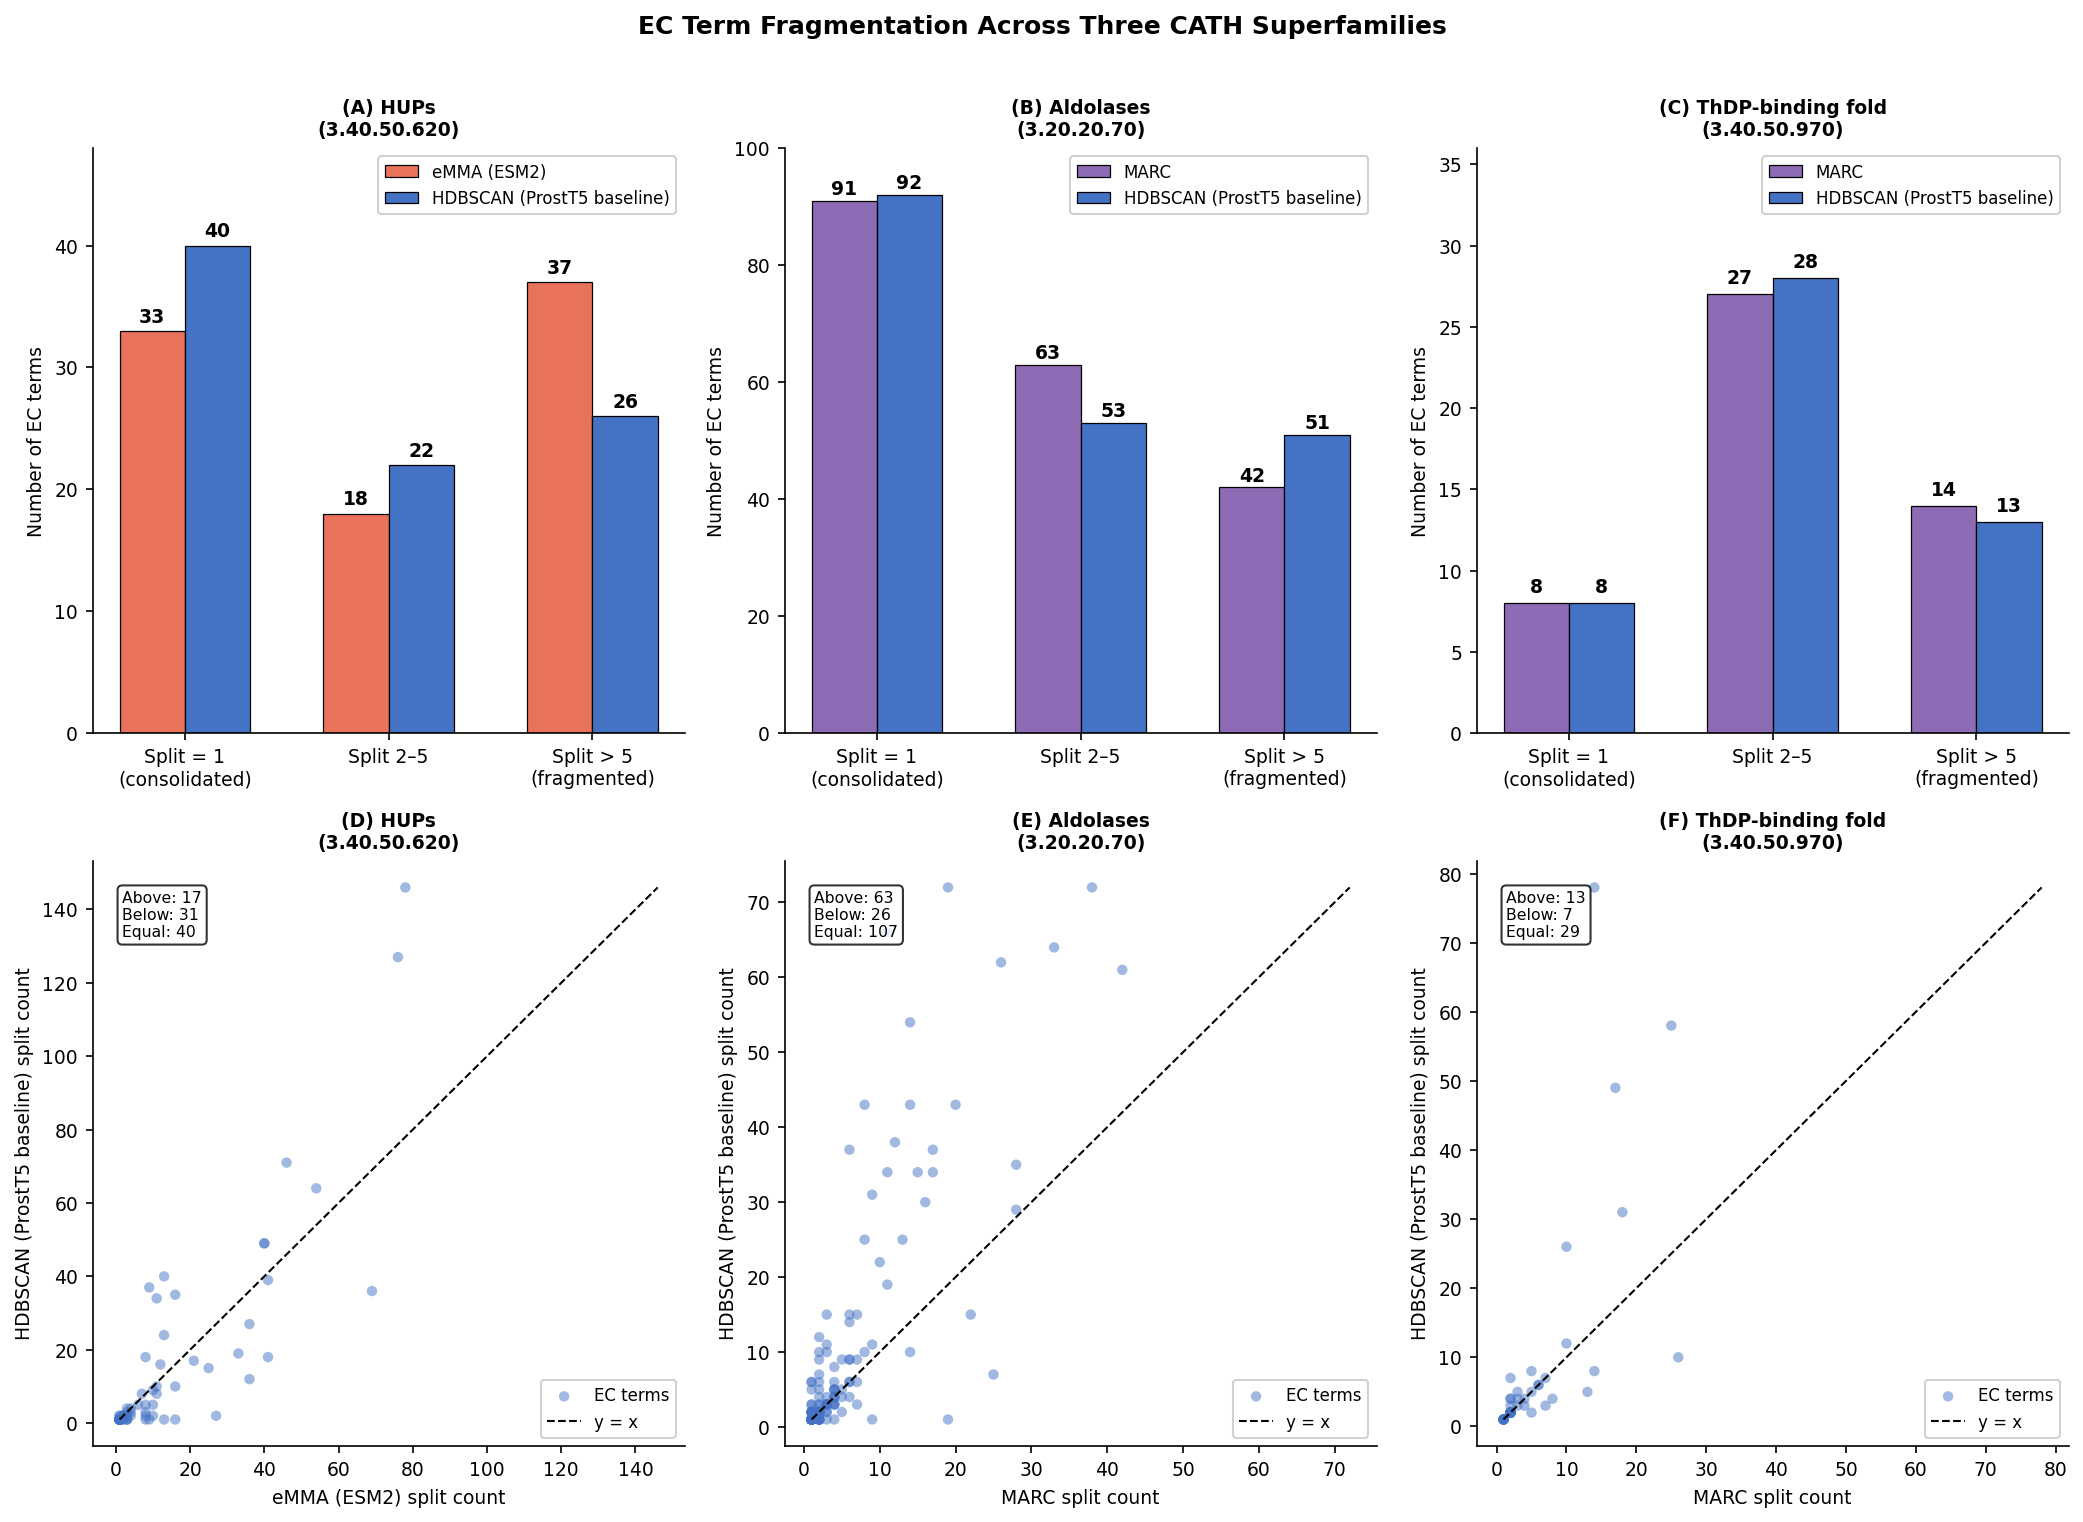

Saved to C:\Users\Janu\funfam_ec_split_counts\EC_split_combined.png


In [10]:
# ── File paths ────────────────────────────────────────────────────────────────
SPLIT_BASE = r'C:\Users\Janu\funfam_ec_split_counts'
OUTPUT     = r'C:\Users\Janu\funfam_ec_split_counts\EC_split_combined.png'

C_EMMA    = '#E8735A'
C_MARC    = '#8E6BB5'
C_HDBSCAN = '#4472C4'

files = {
    'HUPs\n(3.40.50.620)': {
        'base':       SPLIT_BASE + r'\HUPs_eMMA_esm2_EC_split_counts.csv',
        'hdb':        SPLIT_BASE + r'\HUPs_HDBSCAN_prostt5_EC_split_counts.csv',
        'base_label': 'eMMA (ESM2)',
        'base_color': C_EMMA,
    },
    'Aldolases\n(3.20.20.70)': {
        'base':       SPLIT_BASE + r'\Aldolases_MARC_EC_split_counts.csv',
        'hdb':        SPLIT_BASE + r'\Aldolases_HDBSCAN_prostt5_EC_split_counts.csv',
        'base_label': 'MARC',
        'base_color': C_MARC,
    },
    'ThDP-binding fold\n(3.40.50.970)': {
        'base':       SPLIT_BASE + r'\ThDP_MARC_EC_split_counts.csv',
        'hdb':        SPLIT_BASE + r'\ThDP_HDBSCAN_prostt5_EC_split_counts.csv',
        'base_label': 'MARC',
        'base_color': C_MARC,
    },
}

def load_split(path):
    df = pd.read_csv(path)
    df.columns = ['ec4_term', 'split_count']
    return df

def get_bin_counts(s):
    return [
        int((s == 1).sum()),
        int(((s >= 2) & (s <= 5)).sum()),
        int((s > 5).sum()),
    ]

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

bins = ['Split = 1\n(consolidated)', 'Split 2–5', 'Split > 5\n(fragmented)']
panel_labels_top = ['A', 'B', 'C']
panel_labels_bot = ['D', 'E', 'F']

fig, axes = plt.subplots(2, 3, figsize=(14, 10))

for col, (sf_name, sf) in enumerate(files.items()):
    df_base = load_split(sf['base'])
    df_hdb  = load_split(sf['hdb'])
    merged  = pd.merge(df_base, df_hdb, on='ec4_term', suffixes=('_base', '_hdb'))

    base_counts = get_bin_counts(df_base['split_count'].values)
    hdb_counts  = get_bin_counts(df_hdb['split_count'].values)

    # ── Row 0: Summary bar chart ──────────────────────────────────────────────
    ax = axes[0, col]
    x = np.arange(len(bins))
    w = 0.32
    b1 = ax.bar(x - w/2, base_counts, w, color=sf['base_color'],
                edgecolor='black', linewidth=0.6, label=sf['base_label'])
    b2 = ax.bar(x + w/2, hdb_counts,  w, color=C_HDBSCAN,
                edgecolor='black', linewidth=0.6, label='HDBSCAN (ProstT5 baseline)')
    for bar, val in zip(list(b1) + list(b2), base_counts + hdb_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bins, fontsize=8.5)
    ax.set_ylabel('Number of EC terms', fontsize=9)
    ax.set_title(f'({panel_labels_top[col]}) {sf_name}', fontweight='bold', fontsize=9)
    ax.set_ylim(0, max(base_counts + hdb_counts) + 8)
    ax.legend(fontsize=8, framealpha=0.9, loc='upper right')
    style_ax(ax)

    # ── Row 1: Scatter plot ───────────────────────────────────────────────────
    ax = axes[1, col]
    ax.scatter(merged['split_count_base'], merged['split_count_hdb'],
               color=C_HDBSCAN, alpha=0.5, s=25, edgecolors='none', label='EC terms')
    max_val = max(merged['split_count_base'].max(), merged['split_count_hdb'].max())
    ax.plot([1, max_val], [1, max_val], color='black', linewidth=1.0,
            linestyle='--', label='y = x')
    n_above = (merged['split_count_hdb'] > merged['split_count_base']).sum()
    n_below = (merged['split_count_hdb'] < merged['split_count_base']).sum()
    n_equal = (merged['split_count_hdb'] == merged['split_count_base']).sum()
    ax.text(0.05, 0.95, f'Above: {n_above}\nBelow: {n_below}\nEqual: {n_equal}',
            transform=ax.transAxes, fontsize=7.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlabel(f'{sf["base_label"]} split count', fontsize=9)
    ax.set_ylabel('HDBSCAN (ProstT5 baseline) split count', fontsize=9)
    ax.set_title(f'({panel_labels_bot[col]}) {sf_name}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.9, loc='lower right')
    style_ax(ax)

fig.suptitle('EC Term Fragmentation Across Three CATH Superfamilies',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT, dpi=1200, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT}')


## Figure 7 – Impact of contrastive learning on HDBSCAN clustering

Compares ESM2 and ProstT5 contrastive-learning effects on purity, cluster count, and singleton percentage.

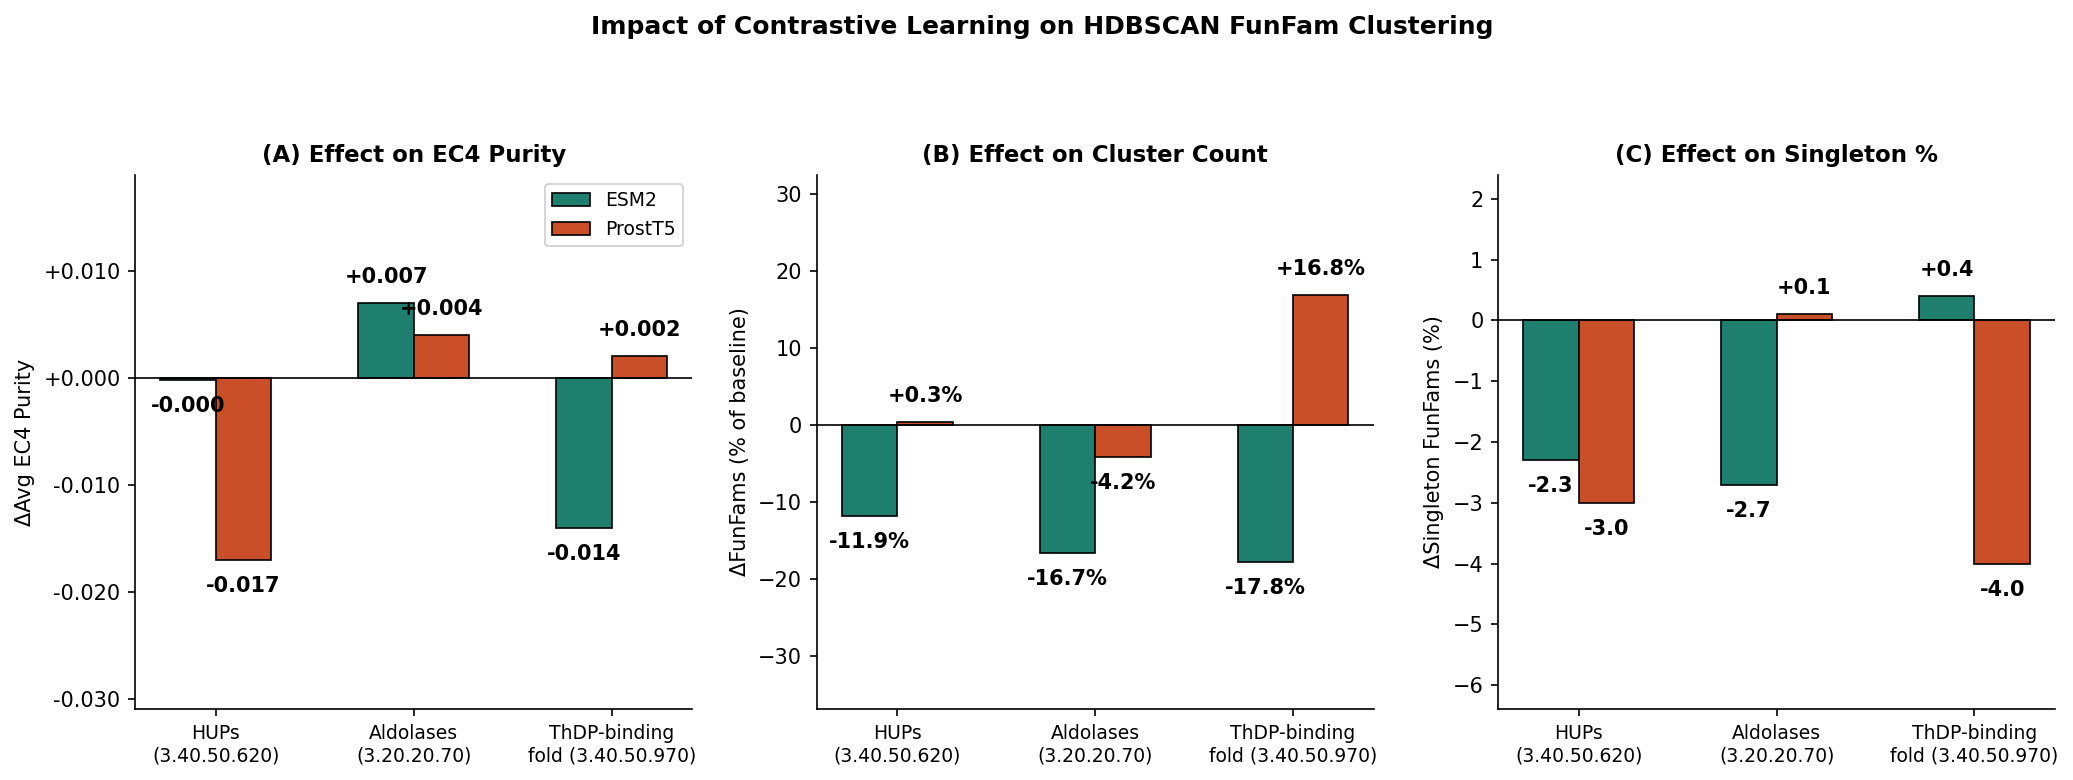

In [12]:
groups = [
    "HUPs\n(3.40.50.620)",
    "Aldolases\n(3.20.20.70)",
    "ThDP-binding\nfold (3.40.50.970)"
]

esm2 = {
    "purity": [-0.0002, 0.007, -0.014],
    "clusters": [-11.9, -16.7, -17.8],
    "singletons": [-2.3, -2.7, 0.4],
}

prostt5 = {
    "purity": [-0.017, 0.004, 0.002],
    "clusters": [0.3, -4.2, 16.8],
    "singletons": [-3.0, 0.1, -4.0],
}

metrics = [
    ("(A) Effect on EC4 Purity", "ΔAvg EC4 Purity", esm2["purity"], prostt5["purity"], (-0.031, 0.019), [-0.03, -0.02, -0.01, 0, 0.01], "{:+.3f}"),
    ("(B) Effect on Cluster Count", "ΔFunFams (% of baseline)", esm2["clusters"], prostt5["clusters"], (-37, 32.5), [-30, -20, -10, 0, 10, 20, 30], "{:+.1f}%"),
    ("(C) Effect on Singleton %", "ΔSingleton FunFams (%)", esm2["singletons"], prostt5["singletons"], (-6.4, 2.4), [-6, -5, -4, -3, -2, -1, 0, 1, 2], "{:+.1f}"),
]

x = np.arange(len(groups))
width = 0.28

colors = {
    "ESM2": "#1f7f6f",
    "ProstT5": "#c94f29",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=150)

fig.suptitle(
    "Impact of Contrastive Learning on HDBSCAN FunFam Clustering",
    fontsize=12,
    fontweight="bold",
    y=1.03
)

for ax, (title, ylabel, vals1, vals2, ylim, yticks, fmt) in zip(axes, metrics):
    bars1 = ax.bar(x - width/2, vals1, width, color=colors["ESM2"],
                   edgecolor="black", linewidth=0.8, label="ESM2")
    bars2 = ax.bar(x + width/2, vals2, width, color=colors["ProstT5"],
                   edgecolor="black", linewidth=0.8, label="ProstT5")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=9)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)

    if ylabel == "ΔAvg EC4 Purity":
        ax.set_yticklabels([f"{t:+.3f}" for t in yticks])

    for bars in (bars1, bars2):
        for bar in bars:
            h = bar.get_height()
            xpos = bar.get_x() + bar.get_width() / 2

            if h >= 0:
                ypos = h + (ylim[1] - ylim[0]) * 0.03
                va = "bottom"
            else:
                ypos = h - (ylim[1] - ylim[0]) * 0.03
                va = "top"

            label = "-0.000" if abs(h) < 0.0005 and ylabel == "ΔAvg EC4 Purity" else fmt.format(h)

            ax.text(
                xpos, ypos, label,
                ha="center", va=va,
                fontsize=10,
                fontweight="bold"
            )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(loc="upper right", frameon=True, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
